# Data Visualisation
### Yuhui Cao

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = '2'
os.environ['HF_HOME'] = '/eresearch/hie/ycao891/Yuhui/hf_cache'
os.environ['TORCH_HOME'] = '/eresearch/hie/ycao891/Yuhui/torch_cache'

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import tifffile as tiff
import random
import torch

%matplotlib inline
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

In [ ]:
from utils.config import TREATMENT_GROUPS, REGION_GROUPS
TREATMENT_GROUPS, REGION_GROUPS

(['HI', 'HI + HYPO', 'SHAM'],
 ['CA3', 'CA4', 'CA12', 'DG', 'PS1', 'PS2', 'TH1', 'TH2'])

In [3]:
ds_root = Path("Neuron Dataset")
[x.name for x in ds_root.iterdir() if x.is_dir()]

['HI', 'HI + HYPO', 'SHAM']

Check if dataset is balanced with respect to treatmen and regions

In [4]:
for i, treatment_group in enumerate(TREATMENT_GROUPS):
    print(f"\nTreatment Group: {treatment_group}")
    for j, region in enumerate(REGION_GROUPS):
        temp_path = ds_root / f"{treatment_group}/{region}"

        img_files = [x for x in temp_path.iterdir() if x.name.lower().endswith("_img.tif")]
        mask_files = [x for x in temp_path.iterdir() if x.name.lower().endswith("_masks.tif")]

        print(f"{region}: Images: {len(img_files)} | Masks: {len(mask_files)}")


Treatment Group: HI
CA3: Images: 10 | Masks: 10
CA4: Images: 10 | Masks: 10
CA12: Images: 10 | Masks: 10
DG: Images: 10 | Masks: 10
PS1: Images: 10 | Masks: 10
PS2: Images: 10 | Masks: 10
TH1: Images: 10 | Masks: 10
TH2: Images: 10 | Masks: 10

Treatment Group: HI + HYPO
CA3: Images: 10 | Masks: 10
CA4: Images: 10 | Masks: 10
CA12: Images: 10 | Masks: 10
DG: Images: 10 | Masks: 10
PS1: Images: 10 | Masks: 10
PS2: Images: 10 | Masks: 10
TH1: Images: 10 | Masks: 10
TH2: Images: 10 | Masks: 10

Treatment Group: SHAM
CA3: Images: 10 | Masks: 10
CA4: Images: 10 | Masks: 10
CA12: Images: 10 | Masks: 10
DG: Images: 10 | Masks: 10
PS1: Images: 10 | Masks: 10
PS2: Images: 10 | Masks: 10
TH1: Images: 10 | Masks: 10
TH2: Images: 10 | Masks: 10


In [5]:
test_img = tiff.imread('Neuron Dataset/HI/CA4/12-067 L CA4 -2_img.tif')
test_img.shape

(1920, 2560, 3)

## Visualise Data
visualise a random sample image from each combination of `treatment_group` and `region`

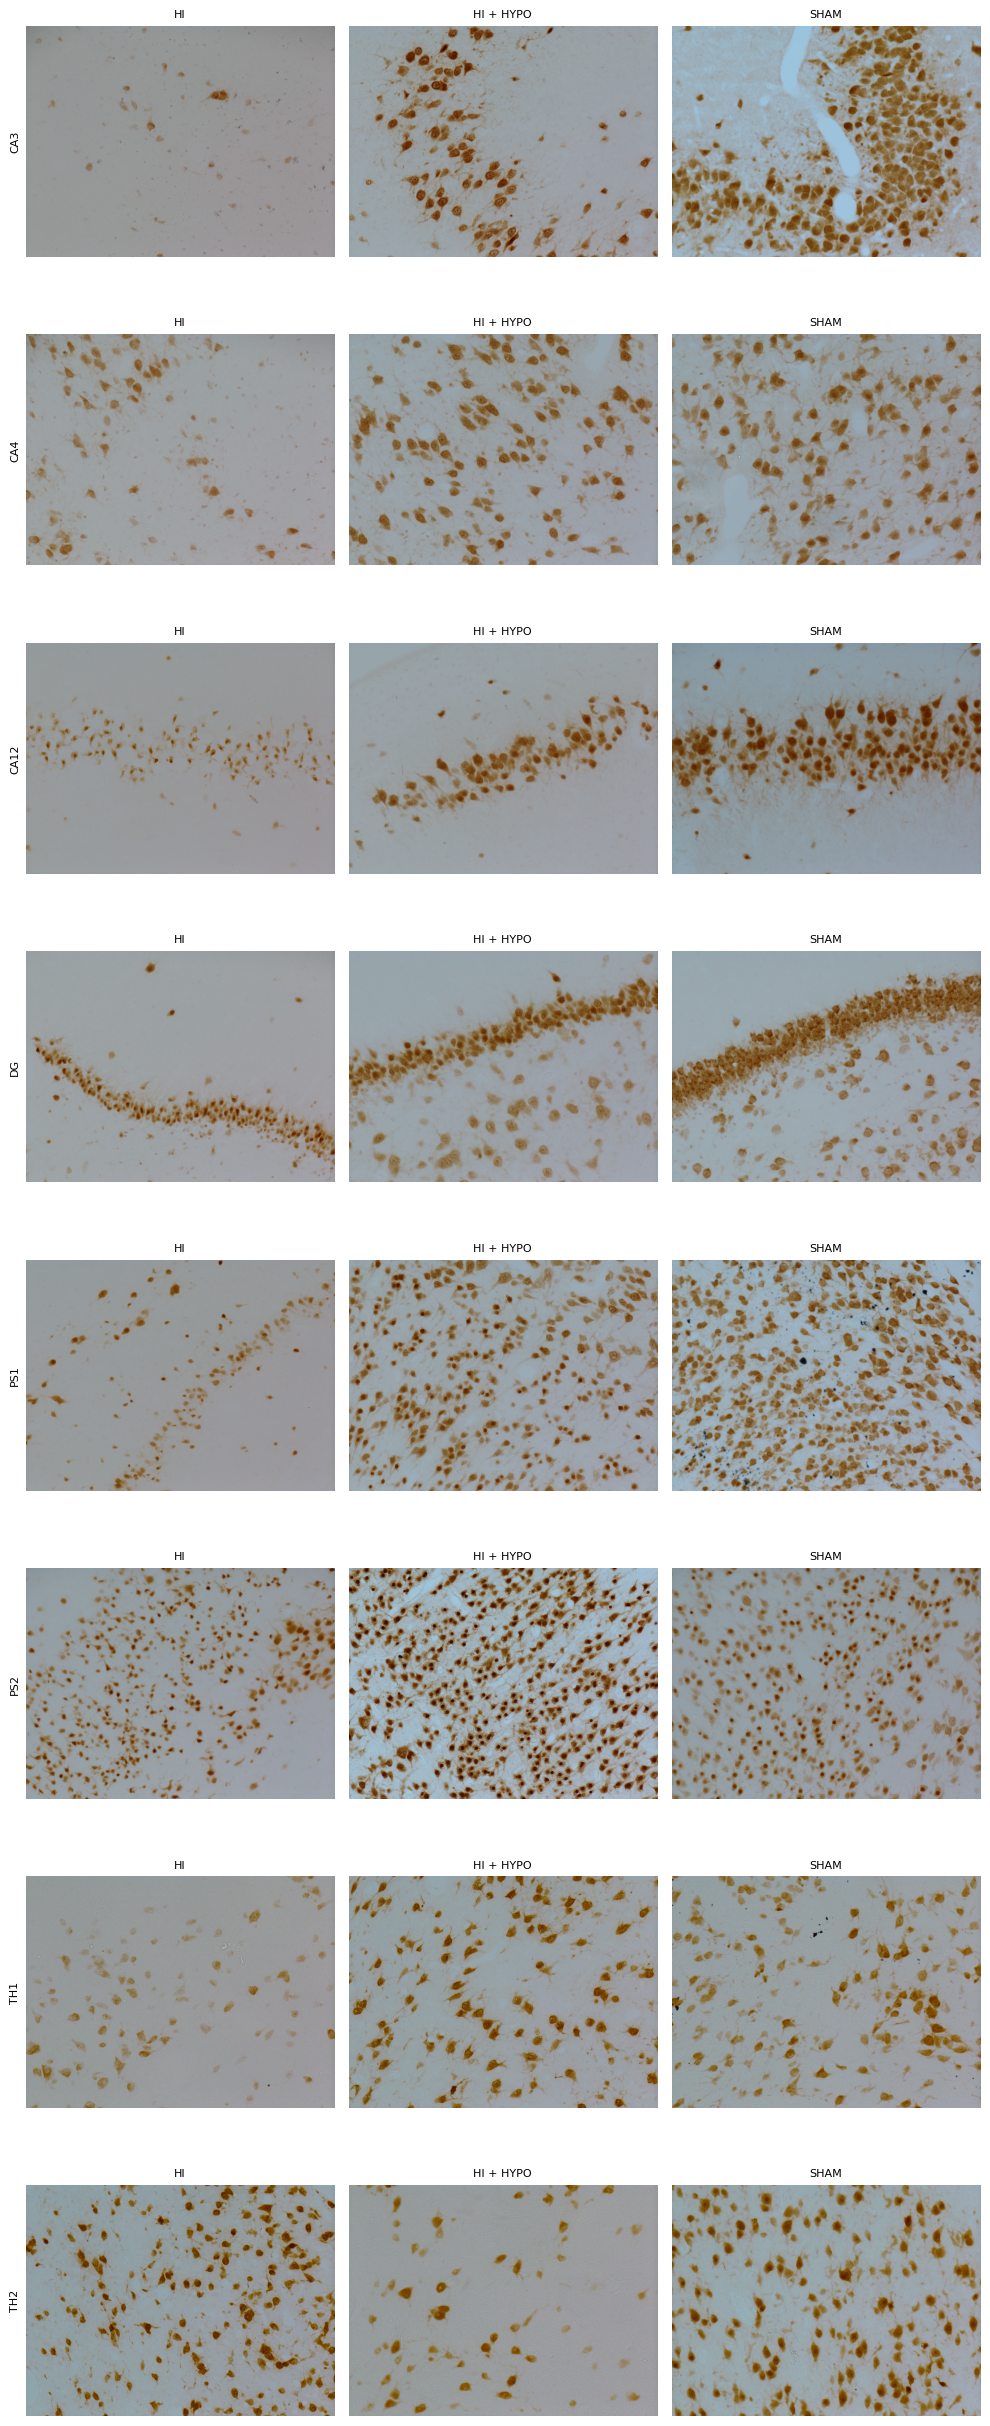

In [6]:
fig, axes = plt.subplots(8, 3, figsize=(10, 25))
for i, region in enumerate(REGION_GROUPS):
    for j, treatment_group in enumerate(TREATMENT_GROUPS):
        temp_path = ds_root / treatment_group / region
        
        # sample a random image
        sample_img = random.choice([x for x in temp_path.iterdir() if x.name.endswith("_img.tif")])
        axes[i, j].imshow(tiff.imread(sample_img, is_ome=False))

        # remove axis values
        axes[i, j].set(xticks=[],yticks=[])

        # treatment group label
        axes[i, j].set_title(treatment_group, fontsize=8)

        # remove black border lines
        for spine in axes[i, j].spines.values():
            spine.set_visible(False)

        # region label
        if j == 0:
            axes[i, j].set_ylabel(region, fontsize=8)

plt.tight_layout()

In [ ]:
from data.load_data import load_image_mask_pairs
base_ds = load_image_mask_pairs(ds_root, TREATMENT_GROUPS, REGION_GROUPS)

Loading data from: Neuron Dataset/HI/CA3


Loading data from: Neuron Dataset/HI/CA4


Loading data from: Neuron Dataset/HI/CA12


Loading data from: Neuron Dataset/HI/DG


Loading data from: Neuron Dataset/HI/PS1


...

Loading data from: Neuron Dataset/SHAM/PS1


Loading data from: Neuron Dataset/SHAM/PS2


Loading data from: Neuron Dataset/SHAM/TH1


Loading data from: Neuron Dataset/SHAM/TH2


Loaded 240 image/mask pairs


In [8]:
len(base_ds)

240

In [9]:
sample = base_ds[12]
img, mask, treatment, group = sample.values()

In [10]:
treatment, group

('HI', 'CA4')

In [11]:
img.min(), img.max()

(0, 189)

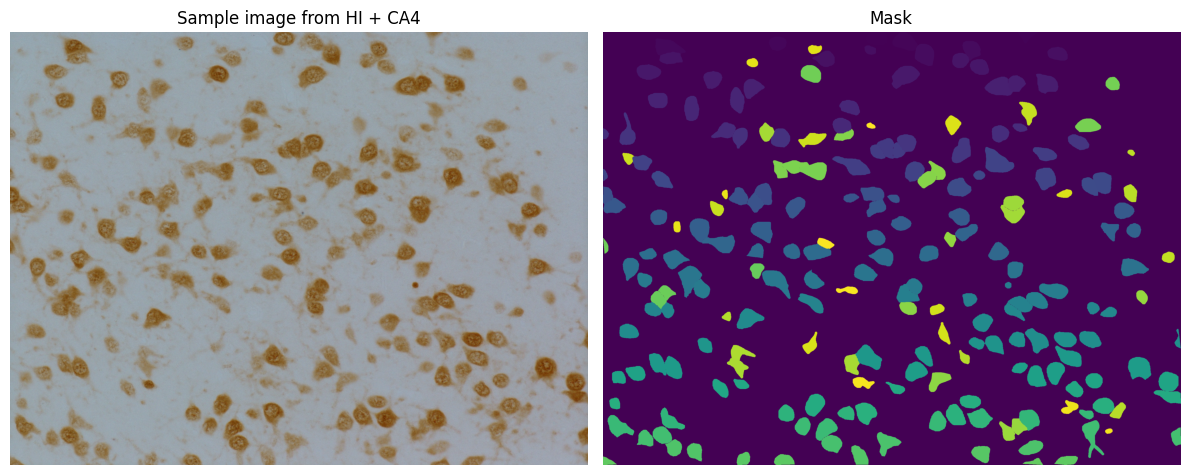

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f'Sample image from {treatment} + {group}')

axes[1].imshow(mask)
axes[1].axis('off')
axes[1].set_title('Mask')
plt.tight_layout()

In [ ]:
from data.load_data import split_dataset

train_ds, val_ds , test_ds = split_dataset(base_ds, test_size=0.2, val_size=0.1, seed=42)

Train size: 168 | Val size: 24 | Test size: 48


In [14]:
import pandas as pd

def split_distribution_df(splits: dict[str, list[dict]]) -> pd.DataFrame:
    """
    Returns a DataFrame showing image counts per treatment/region/split.
    """
    rows = []
    for split_name, pairs in splits.items():
        for d in pairs:
            rows.append({
                'split':     split_name,
                'treatment': d['treatment'],
                'region':    d['region'],
            })

    df = pd.DataFrame(rows)

    # pivot — rows=treatment+region, columns=split, values=count
    summary = df.groupby(['treatment', 'region', 'split']).size().unstack(fill_value=0)

    # add total column
    summary['total'] = summary.sum(axis=1)

    return summary
summary = split_distribution_df({
    'train': train_ds,
    'val':   val_ds,
    'test':  test_ds
})
print(summary)

split             test  train  val  total
treatment region                         
HI        CA12       2      7    1     10
          CA3        2      7    1     10
          CA4        2      7    1     10
          DG         2      7    1     10
          PS1        2      7    1     10
          PS2        2      7    1     10
          TH1        2      7    1     10
          TH2        2      7    1     10
HI + HYPO CA12       2      7    1     10
          CA3        2      7    1     10
          CA4        2      7    1     10
          DG         2      7    1     10
          PS1        2      7    1     10
          PS2        2      7    1     10
          TH1        2      7    1     10
          TH2        2      7    1     10
SHAM      CA12       2      7    1     10
          CA3        2      7    1     10
          CA4        2      7    1     10
          DG         2      7    1     10
          PS1        2      7    1     10
          PS2        2      7    1

In [ ]:
from data.create_dataset import NeuronDataset
from torch.utils.data import DataLoader
from utils.config import PatchConfig
config = PatchConfig()
train_loader = DataLoader(
    NeuronDataset(train_ds, config=config, train=True, augment=True, aug_prob=1.0), 
    batch_size = 1, 
    shuffle=True, 
    num_workers=2, 
    pin_memory=True, 
    persistent_workers=True
)

In [16]:
batch = next(iter(train_loader))
print(len(batch))
test_patch = batch[0]
test_patch.keys()

12


dict_keys(['image', 'neuron_structure', 'treatment_label', 'region_label'])

In [17]:
test_img = test_patch['image'].squeeze(0)
test_img.min(), test_img.max(), test_img.shape

(tensor(-0.7255), tensor(0.5373), torch.Size([3, 256, 256]))

In [18]:
test_mask = test_patch['neuron_structure'].squeeze(0)
test_mask.shape

torch.Size([3, 256, 256])

In [19]:
test_img = (test_img + 1) / 2
test_img = np.transpose(test_img, (1,2,0))

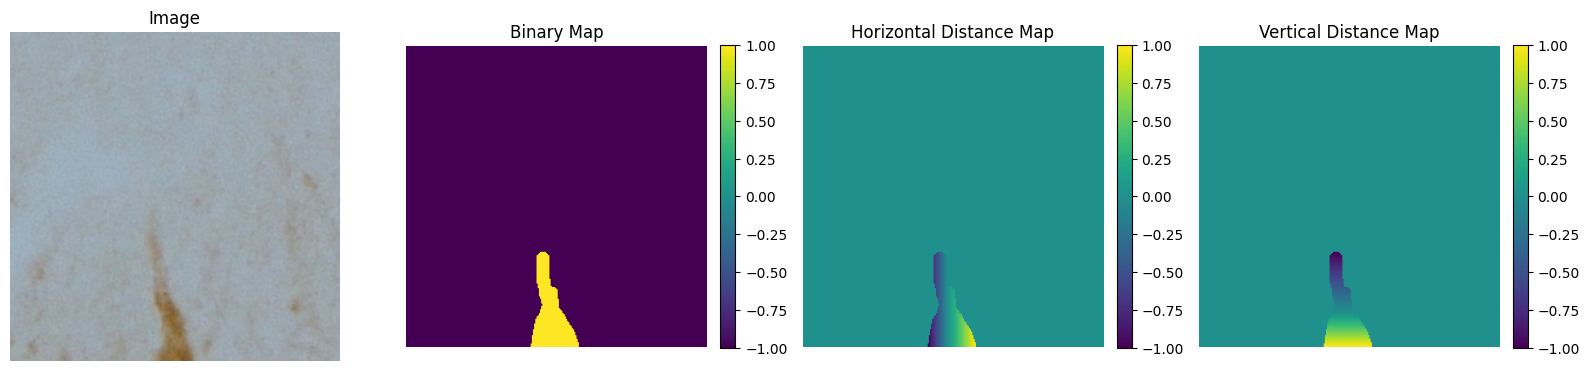

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(16, 12))

axes[0].imshow(test_img)
axes[0].set_title("Image")
axes[0].axis("off")

# Binary map
im1 = axes[1].imshow(test_mask[0])
axes[1].set_title("Binary Map")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Horizontal map
im2 = axes[2].imshow(test_mask[1])
axes[2].set_title("Horizontal Distance Map")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# Vertical map
im3 = axes[3].imshow(test_mask[2])
axes[3].set_title("Vertical Distance Map")
axes[3].axis("off")
fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
from model.mask_diffusion import Mask_Diffusion
from utils.config import DiffusionConfig
import torch

config = DiffusionConfig()
diffusion_model = Mask_Diffusion(config=config).to(config.device)
checkpoint = torch.load('saves/mask_training_3/model_best.pth', map_location=config.device)
diffusion_model.load_state_dict(checkpoint['ema_model'])
diffusion_model.eval()

U-Net parameters: 125,756,611


Mask_Diffusion(
  (model): ConditionedUnet(
    (treatment_emb): Embedding(4, 256)
    (region_emb): Embedding(9, 256)
    (time_mlp): Sequential(
      (0): SinusoidalPositionEmbeddings()
      (1): Linear(in_features=256, out_features=256, bias=True)
      (2): SiLU()
    )
    (cond_proj): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
    )
    (conv0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): ResNetBlock(
        (time_mlp): Linear(in_features=256, out_features=128, bias=True)
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
        (silu): SiLU()
        (residual_proj): C

In [22]:
TREATMENT_GROUPS, REGION_GROUPS

(['HI', 'HI + HYPO', 'SHAM'],
 ['CA3', 'CA4', 'CA12', 'DG', 'PS1', 'PS2', 'TH1', 'TH2'])

In [23]:
import random
n_samples = 4
t_labels = random.choices(TREATMENT_GROUPS, k=n_samples)
r_labels = random.choices(REGION_GROUPS, k=n_samples)
print(t_labels, r_labels)

['HI + HYPO', 'HI', 'SHAM', 'HI'] ['TH2', 'TH2', 'CA12', 'DG']


In [ ]:
from utils.config import TREATMENT_MAP, REGION_MAP

treatment_labels = torch.tensor([TREATMENT_MAP[t] for t in t_labels]).to(config.device)
region_labels = torch.tensor([REGION_MAP[r] for r in r_labels]).to(config.device)

treatment_labels, region_labels

(tensor([1, 0, 2, 0], device='cuda:0'), tensor([7, 7, 2, 3], device='cuda:0'))

In [25]:
samples = diffusion_model.sample(n_samples, treatment_labels, region_labels, steps=50, guidance_scale=2.0).to(config.device)

In [26]:
sample_input = samples.clone()
sample_input.shape

torch.Size([4, 3, 256, 256])

In [27]:
sample_test = samples[0].cpu().numpy()

In [28]:
print(sample_test[0].min(), sample_test[0].max())
print(sample_test[1].min(), sample_test[1].max())
print(sample_test[2].min(), sample_test[2].max())
sample_test.shape

-1.0 1.0
-0.9901166 0.97098213
-0.99580765 0.9968041


(3, 256, 256)

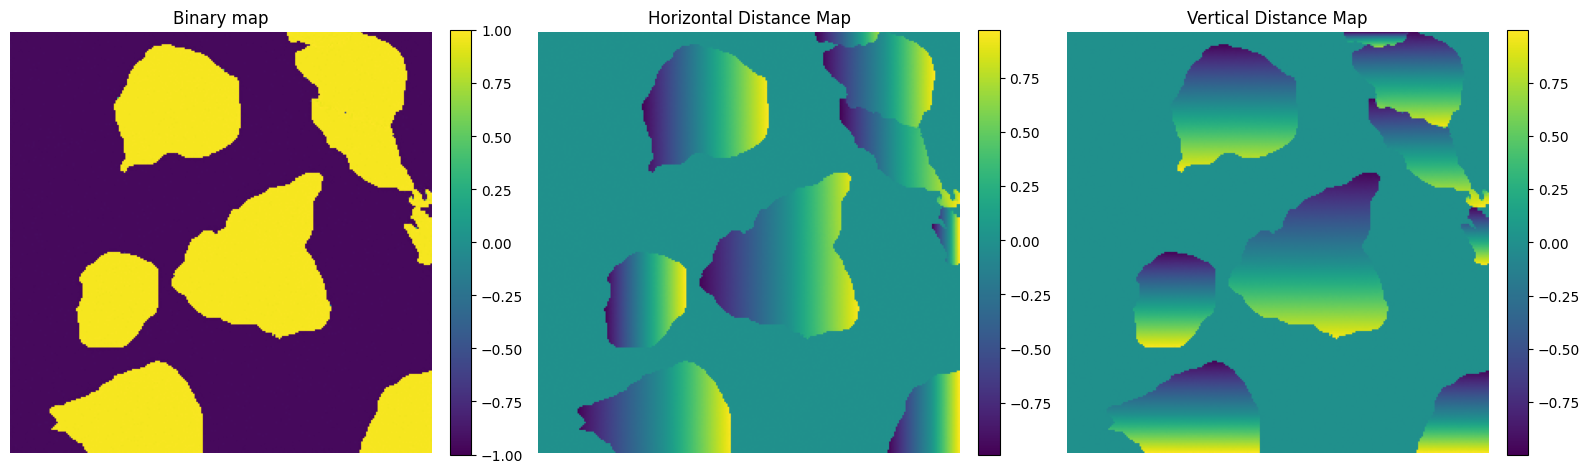

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 16))

# Binary
im0 = axes[0].imshow(sample_test[0])
axes[0].axis('off')
axes[0].set_title('Binary map')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Horizontal HoVer
im1 = axes[1].imshow(sample_test[1])
axes[1].axis('off')
axes[1].set_title('Horizontal Distance Map')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Vertical HoVer
im2 = axes[2].imshow(sample_test[2])
axes[2].axis('off')
axes[2].set_title('Vertical Distance Map')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

In [30]:
from skimage import filters
from scipy.ndimage import gaussian_filter

# binary_map, h_map, v_map = test_mask.cpu().numpy()
binary_map, h_map, v_map = sample_test

In [31]:
horizontal_map = gaussian_filter(h_map, sigma=0.5)
vertical_map   = gaussian_filter(v_map, sigma=0.5)

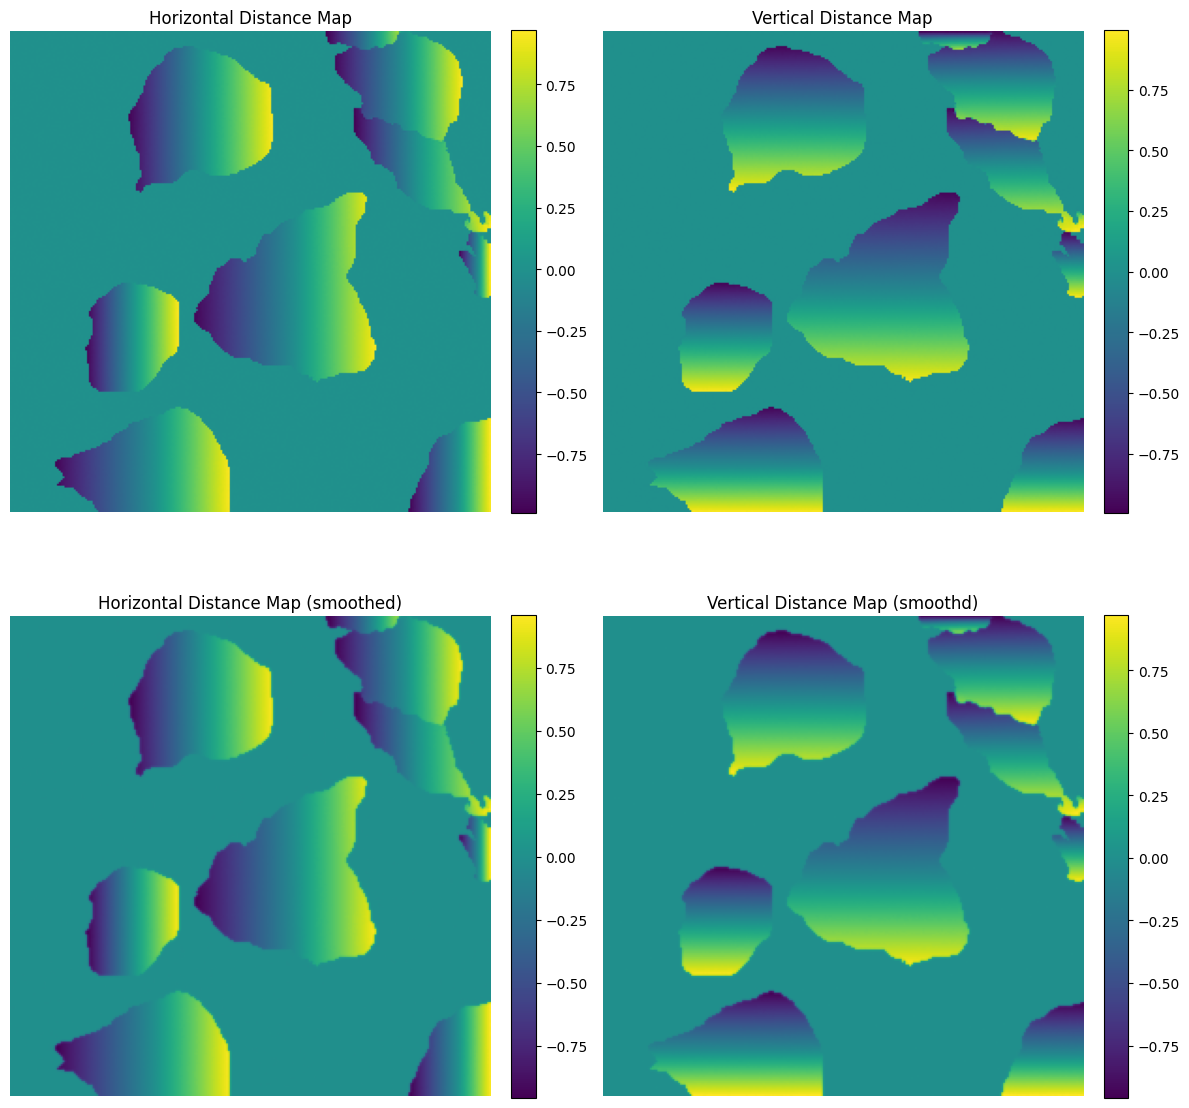

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Horizontal map
im0 = axes[0,0].imshow(h_map)
axes[0,0].set_title("Horizontal Distance Map")
axes[0,0].axis("off")
fig.colorbar(im0, ax=axes[0,0], fraction=0.046, pad=0.04)

# Vertical map
im1 = axes[0, 1].imshow(v_map)
axes[0, 1].set_title("Vertical Distance Map")
axes[0, 1].axis("off")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Horizontal map
im2 = axes[1, 0].imshow(horizontal_map)
axes[1, 0].set_title("Horizontal Distance Map (smoothed)")
axes[1, 0].axis("off")
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Vertical map
im3 = axes[1,1].imshow(vertical_map)
axes[1, 1].set_title("Vertical Distance Map (smoothd)")
axes[1, 1].axis("off")
fig.colorbar(im3, ax=axes[1,1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [33]:
# grad_h, grad_v = filters.sobel_h(h_map), filters.sobel_v(v_map)
grad_h , grad_v = filters.sobel_h(horizontal_map), filters.sobel_v(vertical_map)

energy_landscape = np.sqrt(grad_h**2 + grad_v**2)
energy_landscape_normalised = (energy_landscape - energy_landscape.min()) / (energy_landscape.max() - energy_landscape.min() + 1e-8)

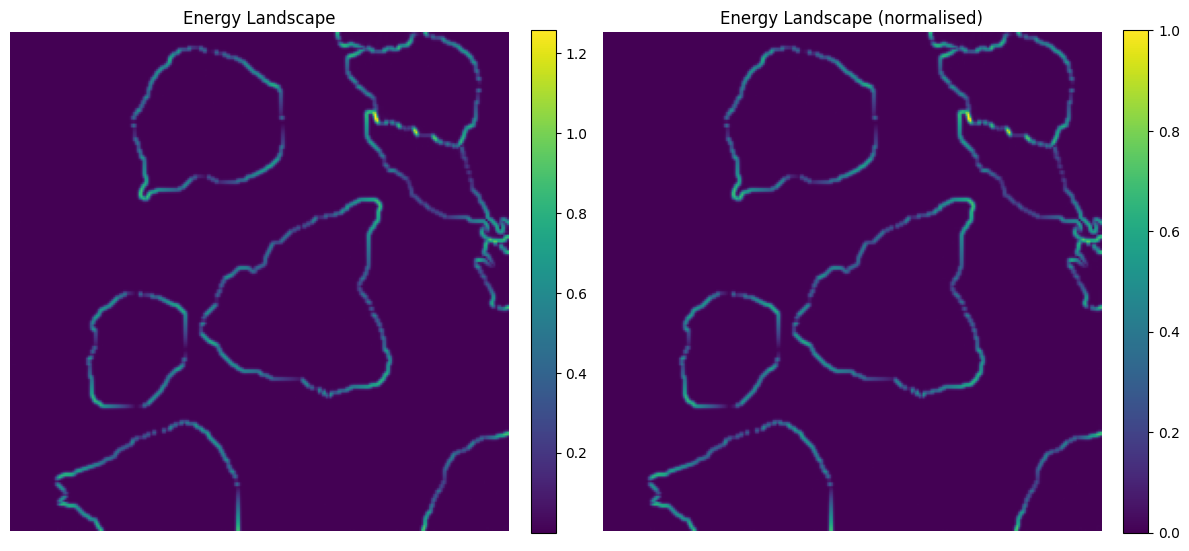

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 16))

im0 = axes[0].imshow(energy_landscape)
axes[0].axis('off')
axes[0].set_title('Energy Landscape')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(energy_landscape_normalised)
axes[1].axis('off')
axes[1].set_title('Energy Landscape (normalised)')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()

In [35]:
from skimage import morphology, measure

dist = np.sqrt(horizontal_map**2 + vertical_map**2)
seed_mask_1 = dist < 0.4
seed_mask_1 &= (binary_map > 0.5)

seed_mask_2 = morphology.binary_opening(seed_mask_1, morphology.disk(2))
seed_mask_2 = morphology.binary_closing(seed_mask_1, morphology.disk(2))
seed_mask_2 = morphology.remove_small_objects(seed_mask_1, min_size=25)

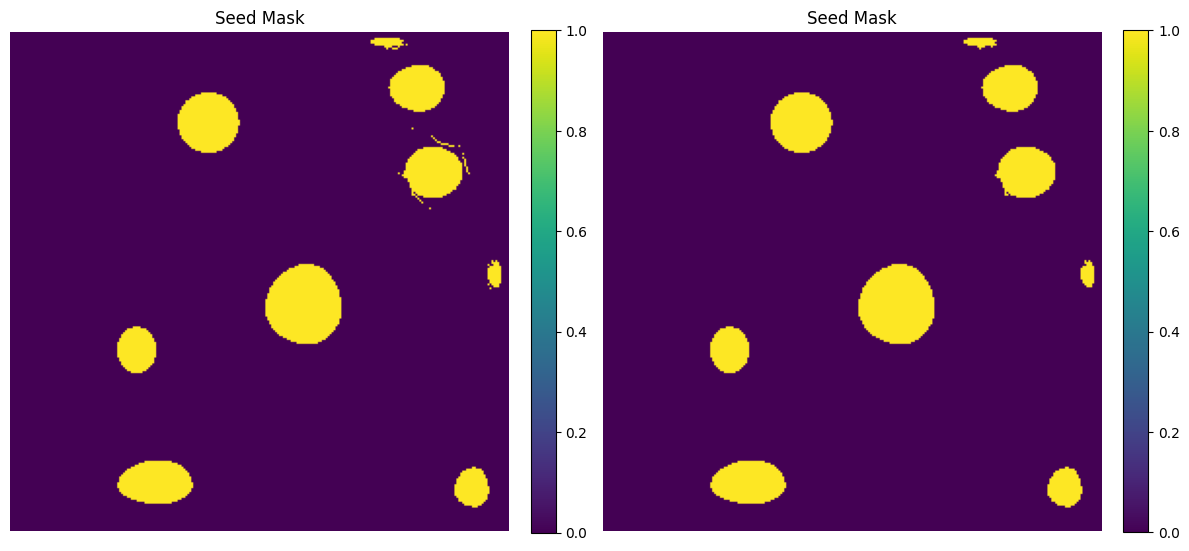

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 12))

im0 = axes[0].imshow(seed_mask_1)
axes[0].axis('off')
axes[0].set_title('Seed Mask')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(seed_mask_2)
axes[1].axis('off')
axes[1].set_title('Seed Mask')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()

In [37]:
markers = measure.label(seed_mask_2)
for region in measure.regionprops(markers):
    if region.area < 25:
        markers[markers == region.label] = 0

markers = measure.label(markers > 0)

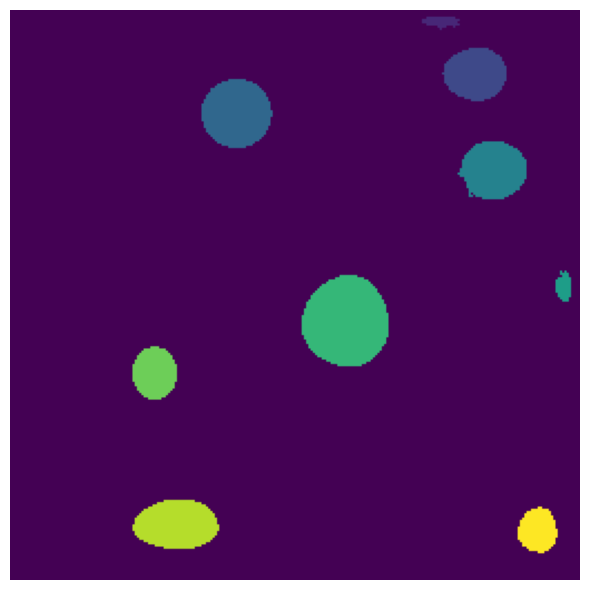

In [38]:
fig, axes = plt.subplots(figsize=(6,8))

axes.imshow(markers)
axes.axis('off')

plt.tight_layout()
plt.show()

[1 2 3 4 5 6 7 8 9]


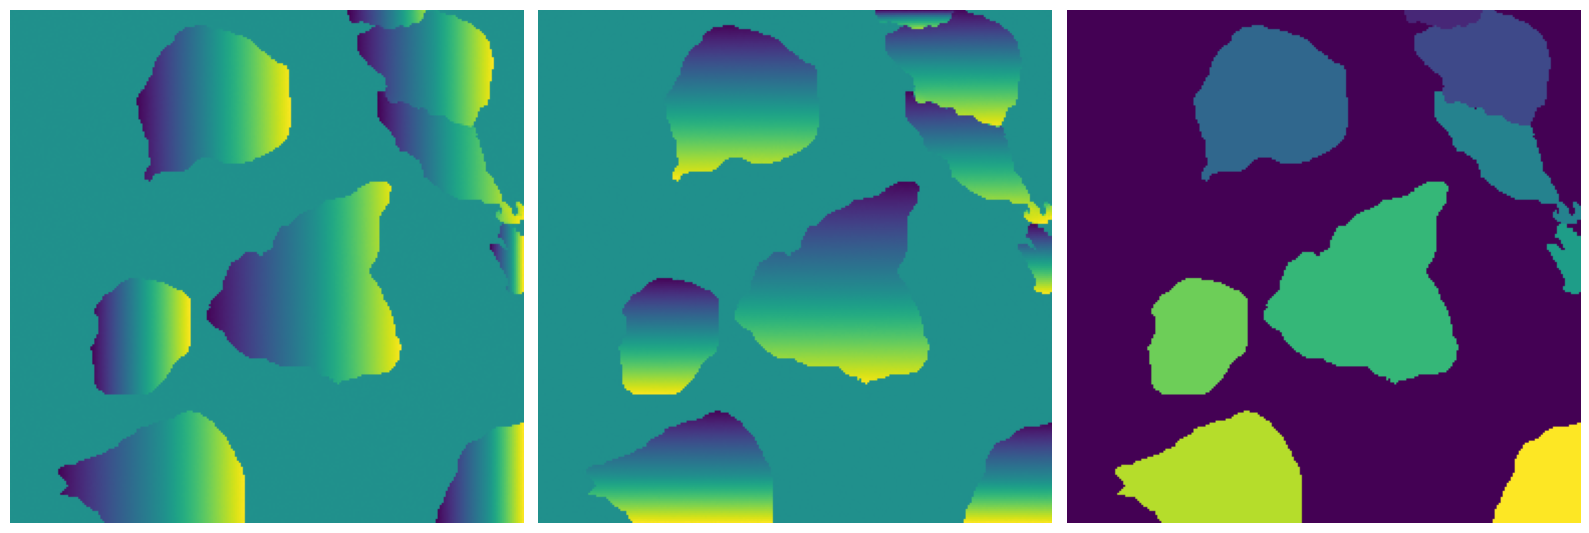

In [ ]:
from skimage.segmentation import watershed
from utils.util import watershed_postprocess
# instance_mask = watershed_postprocess(sample0, threshold=0.5, hover_threshold=0.25)
instance_map = watershed(
    energy_landscape,
    markers,
    mask=(binary_map > 0.5)
)
instance_map = morphology.remove_small_objects(instance_map, min_size=25)
print(np.unique(instance_map[instance_map != 0]))
fig, axes = plt.subplots(1, 3, figsize=(16, 16))

axes[0].imshow(h_map)
axes[0].axis('off')
axes[1].imshow(v_map)
axes[1].axis('off')
axes[2].imshow(instance_map)
axes[2].axis('off')
plt.tight_layout()

In [ ]:
from model.controlnetImage_diffusion import ControlNetImageDiffusion

checkpoint_image = torch.load(f'saves/image_training_2/image_best.pth', map_location=config.device)

image_model = ControlNetImageDiffusion(
    config = config,
    pretrained_model= 'sd-legacy/stable-diffusion-v1-5',
    train_unet = False,
    unfreeze_last_n_down_blocks=0,
    use_unet_lora=True,
    lora_rank=8
).to(config.device)

image_model.controlnet.load_state_dict(checkpoint_image['ema_controlnet'])
image_model.label_conditioner.load_state_dict(checkpoint_image['ema_label_conditioner'])
image_model.unet.load_state_dict(checkpoint_image['unet_lora'], strict=False)
image_model.eval()

OutOfMemoryError: CUDA out of memory. Tried to allocate 50.00 MiB. GPU 0 has a total capacity of 31.73 GiB of which 42.19 MiB is free. Process 40858 has 6.63 GiB memory in use. Process 35886 has 6.64 GiB memory in use. Including non-PyTorch memory, this process has 18.41 GiB memory in use. Of the allocated memory 17.86 GiB is allocated by PyTorch, and 191.69 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 

(tensor(0.0554, device='cuda:0'), tensor(0.9820, device='cuda:0'))

In [60]:
image_samples = image_model.sample(sample_input, treatment_labels, region_labels, steps=50, guidance_scale=2.0)

In [61]:
image_samples.shape

torch.Size([4, 3, 256, 256])

In [62]:
image_sample = image_samples.squeeze(0).cpu().numpy()
image_sample.shape

(4, 3, 256, 256)

In [63]:
sample_input.shape

torch.Size([4, 3, 256, 256])

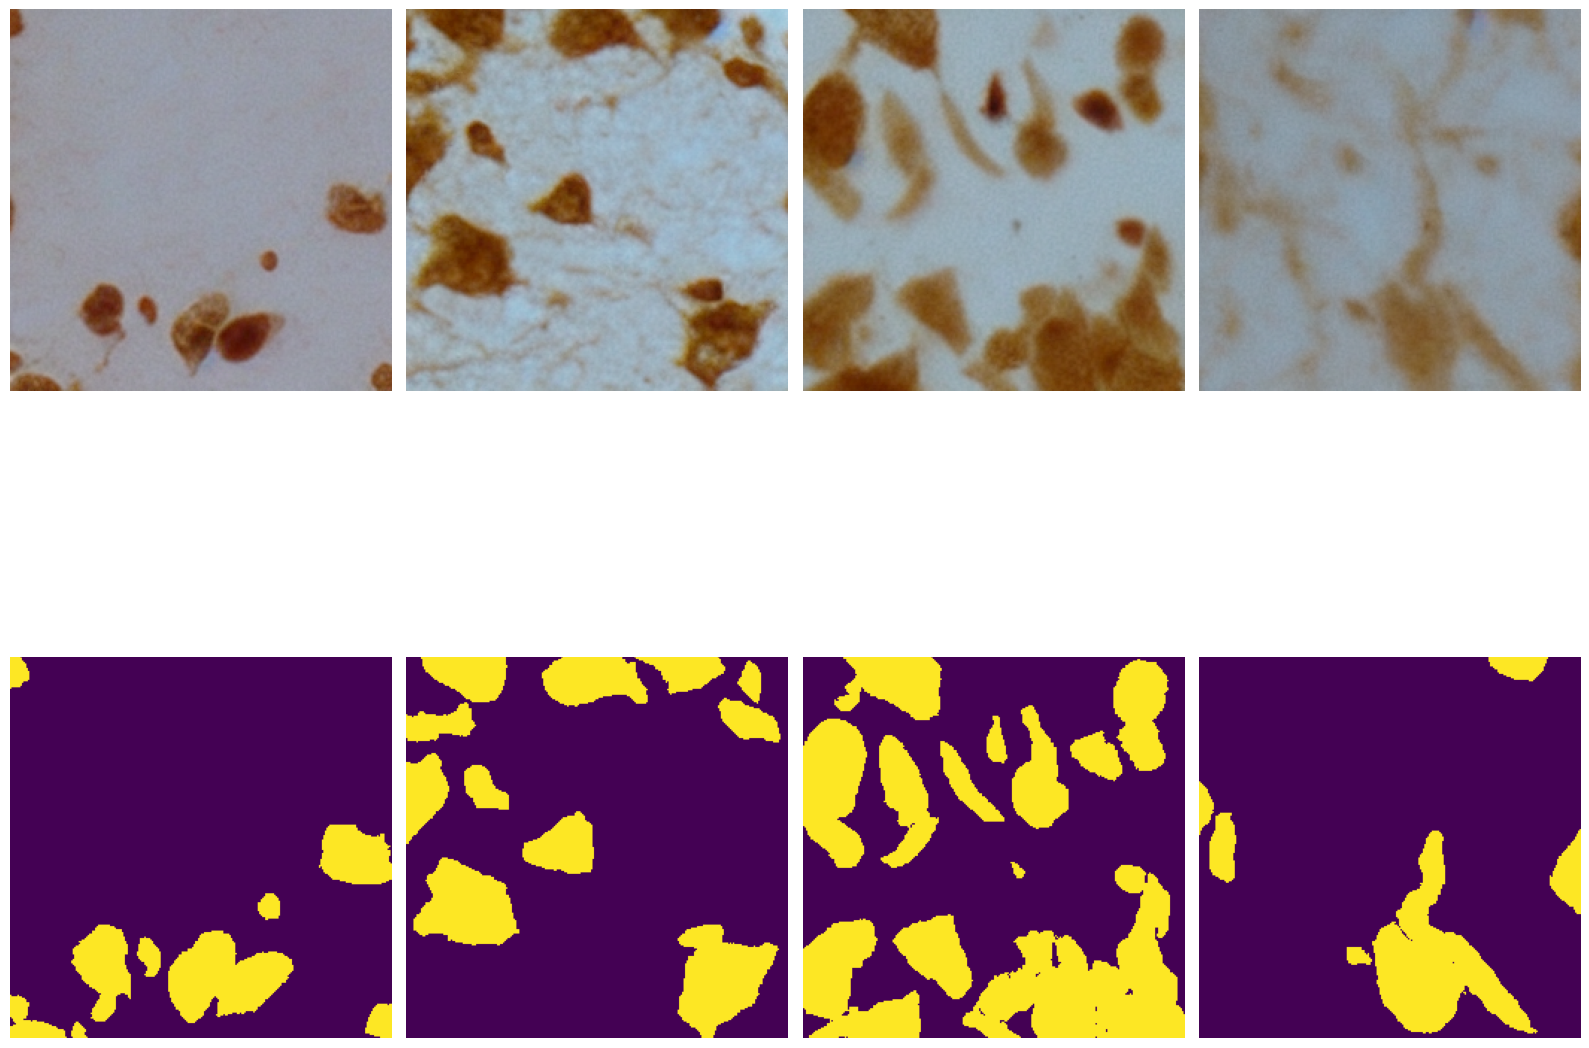

In [ ]:
fig, axes = plt.subplots(2,4, figsize=(16,16))

for i in range(image_samples.shape[0]):
    axes[0, i].imshow(np.transpose(image_samples[i].cpu().numpy(), (1,2,0)))
    axes[0, i].axis('off')

    axes[1, i].imshow(sample_input[i,0].cpu().numpy())
    axes[1, i].axis('off')
    
plt.tight_layout()
plt.show()